In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import subprocess
import os

# 1: Enter file path

In [5]:
file_path = "E:\\Desktop\\Timepix\\Data with He Ni\\same_intensity_timepix\\0.5s_1f_1.csv"
# file_path = "E:\\Desktop\\Timepix\\Data with He Ni\\data_with_qiskit_idk.csv"

# 2: .tpx3 to .csv

In [ ]:
def process_raw_folder(raw_folder_path: str):
    if not os.path.isdir(raw_folder_path):
        raise ValueError(f"Directory does not exist: {raw_folder_path}")

    # Call the C++ executable
    result = subprocess.run(
        ["./tpx3_to_csv", raw_folder_path],
        capture_output=True,
        text=True
    )
    
    if result.returncode != 0:
        raise RuntimeError(f"C++ conversion failed: {result.stderr}")
    
    print(result.stdout)

    
raw_path = "D:\\Desktop\\Timepix\\Data with He Ni\\same_intensity_tpx"
process_raw_folder(raw_path)

# 3: Filter Data

In [6]:
csv_path = file_path.replace('.tpx3', '.csv')
data_main = pd.read_csv(csv_path)
data_main

,ChipNumber,Mode,TriggerCounter,TDC_timestamp,GlobalTime,ChipToA,ToT,x,y
0,0,0,NaN,NaN,0.001218,398825,125,83,184
1,0,0,NaN,NaN,0.001218,398825,50,78,176
2,0,0,NaN,NaN,0.001218,399100,25,73,176
3,0,0,NaN,NaN,0.001219,399575,150,82,182
4,0,0,NaN,NaN,0.001219,399550,125,78,173
...,...,...,...,...,...,...,...,...,...
11818871,0,0,NaN,NaN,0.500039,326500,150,51,77
11818872,0,0,NaN,NaN,0.500036,323500,25,53,69
11818873,0,0,NaN,NaN,0.500032,319775,50,62,76
11818874,0,0,NaN,NaN,0.500002,289800,150,84,179


i. Unwrap Global Time

In [4]:
def unwrap_toa_inplace(data: pd.DataFrame, toa_col: str) -> None:
    reset_value=26.8435456
    add_value = 0
    toa_original = data[toa_col].values.copy()  # numpy array for speed
    toa = data[toa_col].values.copy()

    for i in range(1, len(toa)):
        if (toa_original[i] < toa_original[i - 1]) and (abs(toa_original[i]-reset_value)<=1):
            add_value += reset_value
        toa[i] += add_value
    
    data["ToA_corrected"] = toa

unwrap_toa_inplace(data_main, "GlobalTime")
data_main

,ChipNumber,Mode,TriggerCounter,TDC_timestamp,GlobalTime,ChipToA,ToT,x,y,ToA_corrected
0,0,0,NaN,NaN,0.001074,254300,25,79,184,0.001074
1,0,0,NaN,NaN,0.001074,255075,75,78,180,0.001074
2,0,0,NaN,NaN,0.001074,254950,75,82,188,0.001074
3,0,0,NaN,NaN,0.001074,254975,25,90,183,0.001074
4,0,0,NaN,NaN,0.001074,254950,75,93,178,0.001074
...,...,...,...,...,...,...,...,...,...,...
23603060,0,0,NaN,NaN,1.000050,216575,100,66,83,1.000050
23603061,0,0,NaN,NaN,1.000035,200975,200,94,180,1.000035
23603062,0,0,NaN,NaN,1.000050,216125,450,55,71,1.000050
23603063,0,0,NaN,NaN,1.000053,219325,175,53,77,1.000053


ii. Visualize

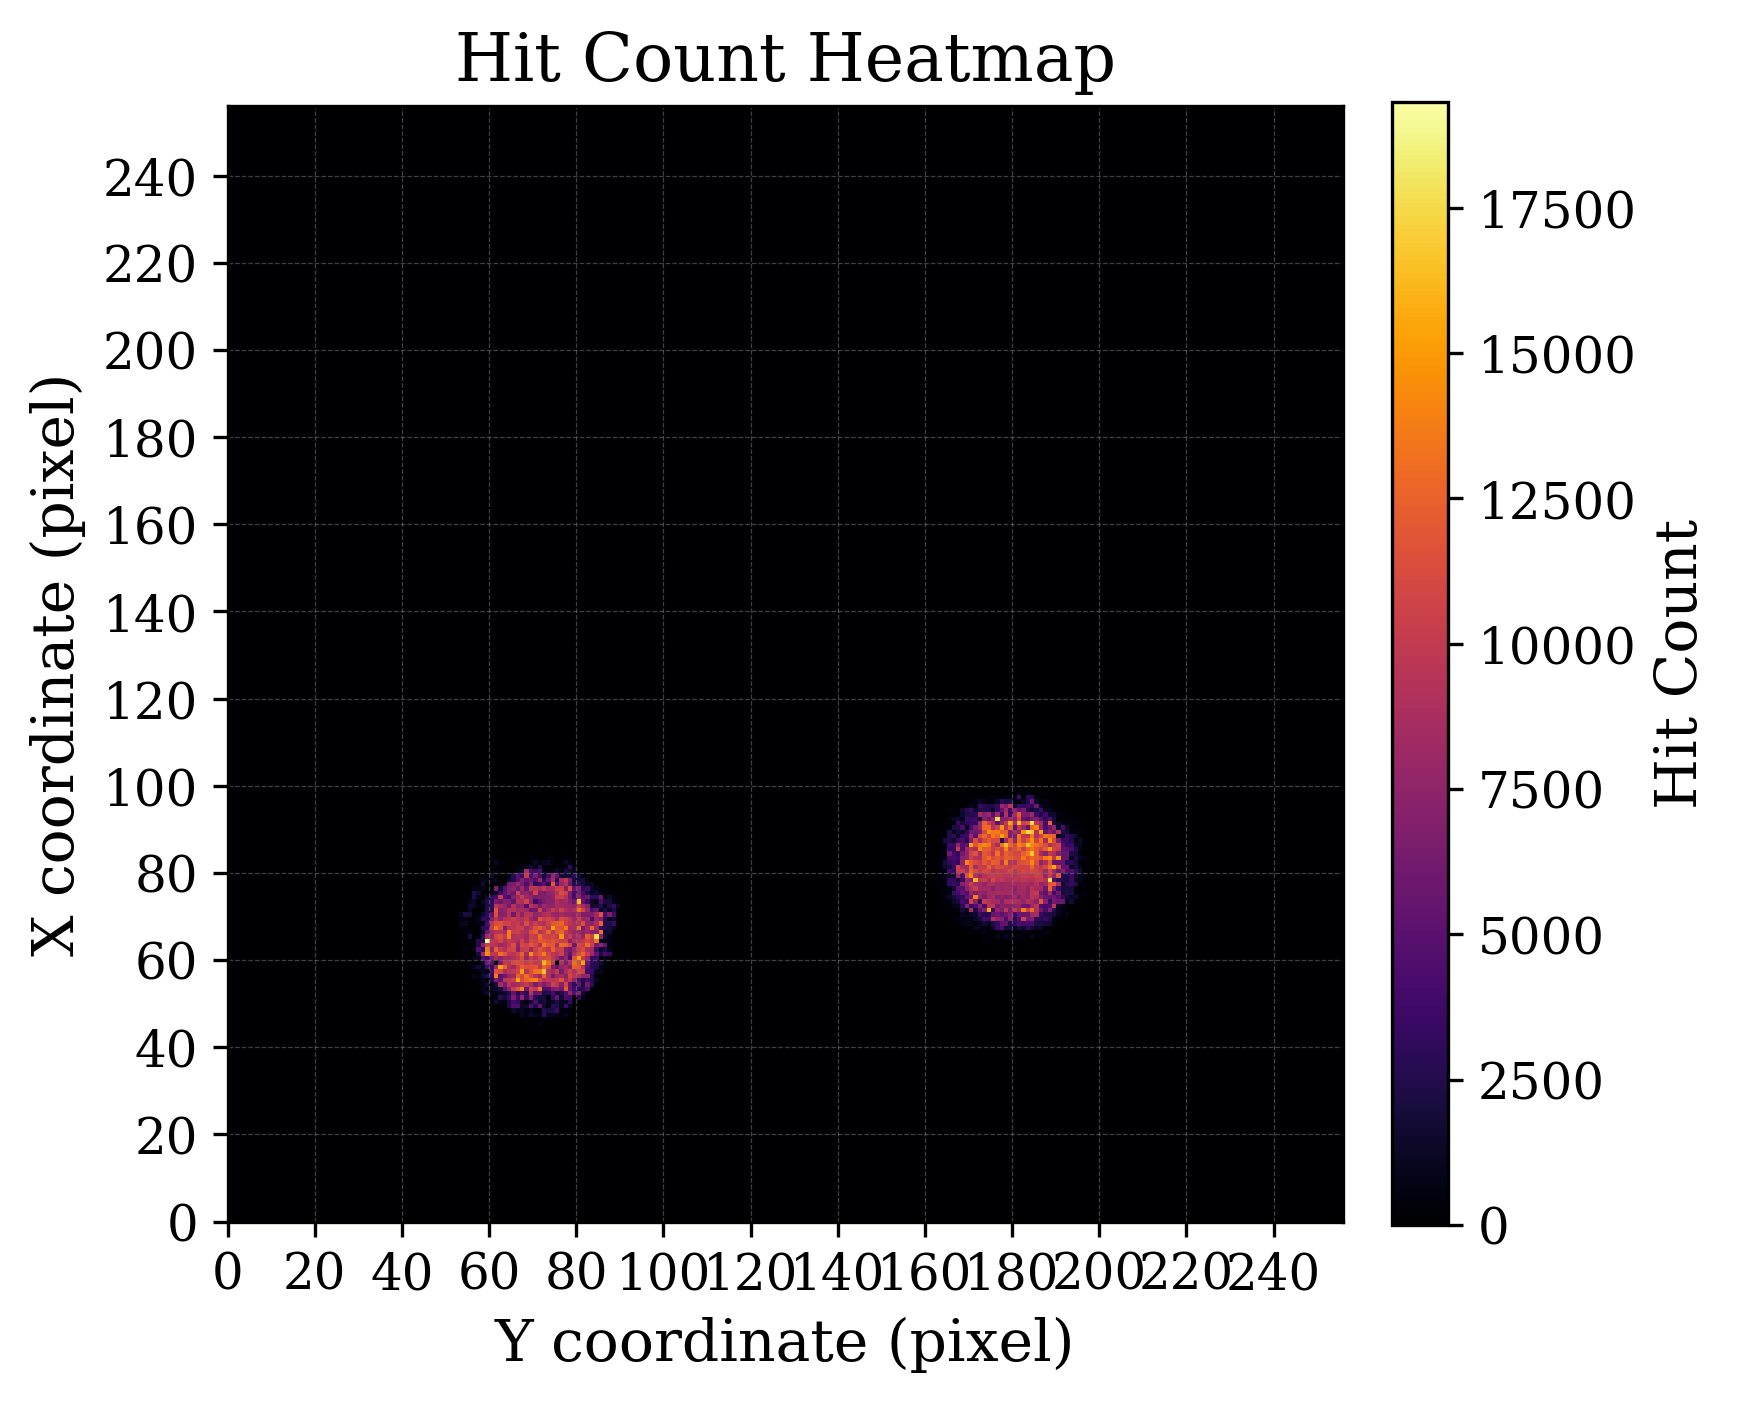

In [7]:
# Optional filter on ToT
data = data_main.copy()

# Group by (x, y) and count entries
agg_data = data.groupby(['x', 'y']).size().reset_index(name='Count')

# Full 256x256 pixel grid
x_full = np.arange(0, 256)
y_full = np.arange(0, 256)
full_grid = pd.MultiIndex.from_product([x_full, y_full], names=['x', 'y']).to_frame(index=False)

# Merge and fill missing counts with 0
full_data = pd.merge(full_grid, agg_data, on=['x', 'y'], how='left')
full_data['Count'] = full_data['Count'].fillna(0)

# Pivot for heatmap
heatmap_data = full_data.pivot(index='x', columns='y', values='Count')

# --- Plotting ---
plt.rcParams.update({
    "font.size": 14,
    "font.family": "serif",   # For professional look; use 'sans-serif' if journal prefers
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 300
})

fig, ax = plt.subplots(figsize=(6, 5.5))  # Use size appropriate for 1-column journal layout

# Heatmap
cax = ax.imshow(
    heatmap_data.values,
    cmap='inferno',
    origin='lower',
    vmin=0,
    vmax=full_data['Count'].max(),
    extent=[0, 256, 0, 256],
    interpolation='none'
)

# Colorbar
cbar = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Hit Count', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Labels
ax.set_xlabel('Y coordinate (pixel)')
ax.set_ylabel('X coordinate (pixel)')
ax.set_title('Hit Count Heatmap')

# Grid settings
ax.set_xticks(np.arange(0, 257, 20))
ax.set_yticks(np.arange(0, 257, 20))
ax.grid(which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.5)

# Minor grid for clarity if needed
# ax.set_xticks(np.arange(0.5, 256.5, 1), minor=True)
# ax.set_yticks(np.arange(0.5, 256.5, 1), minor=True)
# ax.grid(which='minor', linestyle='-', linewidth=0.2, color='gray', alpha=0.3)

# Tight and square layout
ax.set_aspect('equal')
plt.tight_layout()

# Save figure (optional)
# plt.savefig("hit_count_heatmap.png", dpi=600, bbox_inches='tight')

plt.show()


iii. Manually add X and Y coordinates for both clusters

In [8]:
data1 = data_main[(data_main["x"] < 90) & (data_main["x"] > 40) & (data_main["y"] < 100) & (data_main["y"] > 50)]
data2 = data_main[(data_main["x"] < 100) & (data_main["x"] > 60) & (data_main["y"] < 200) & (data_main["y"] > 160)]
data_processed = pd.concat([data1, data2], ignore_index=True)

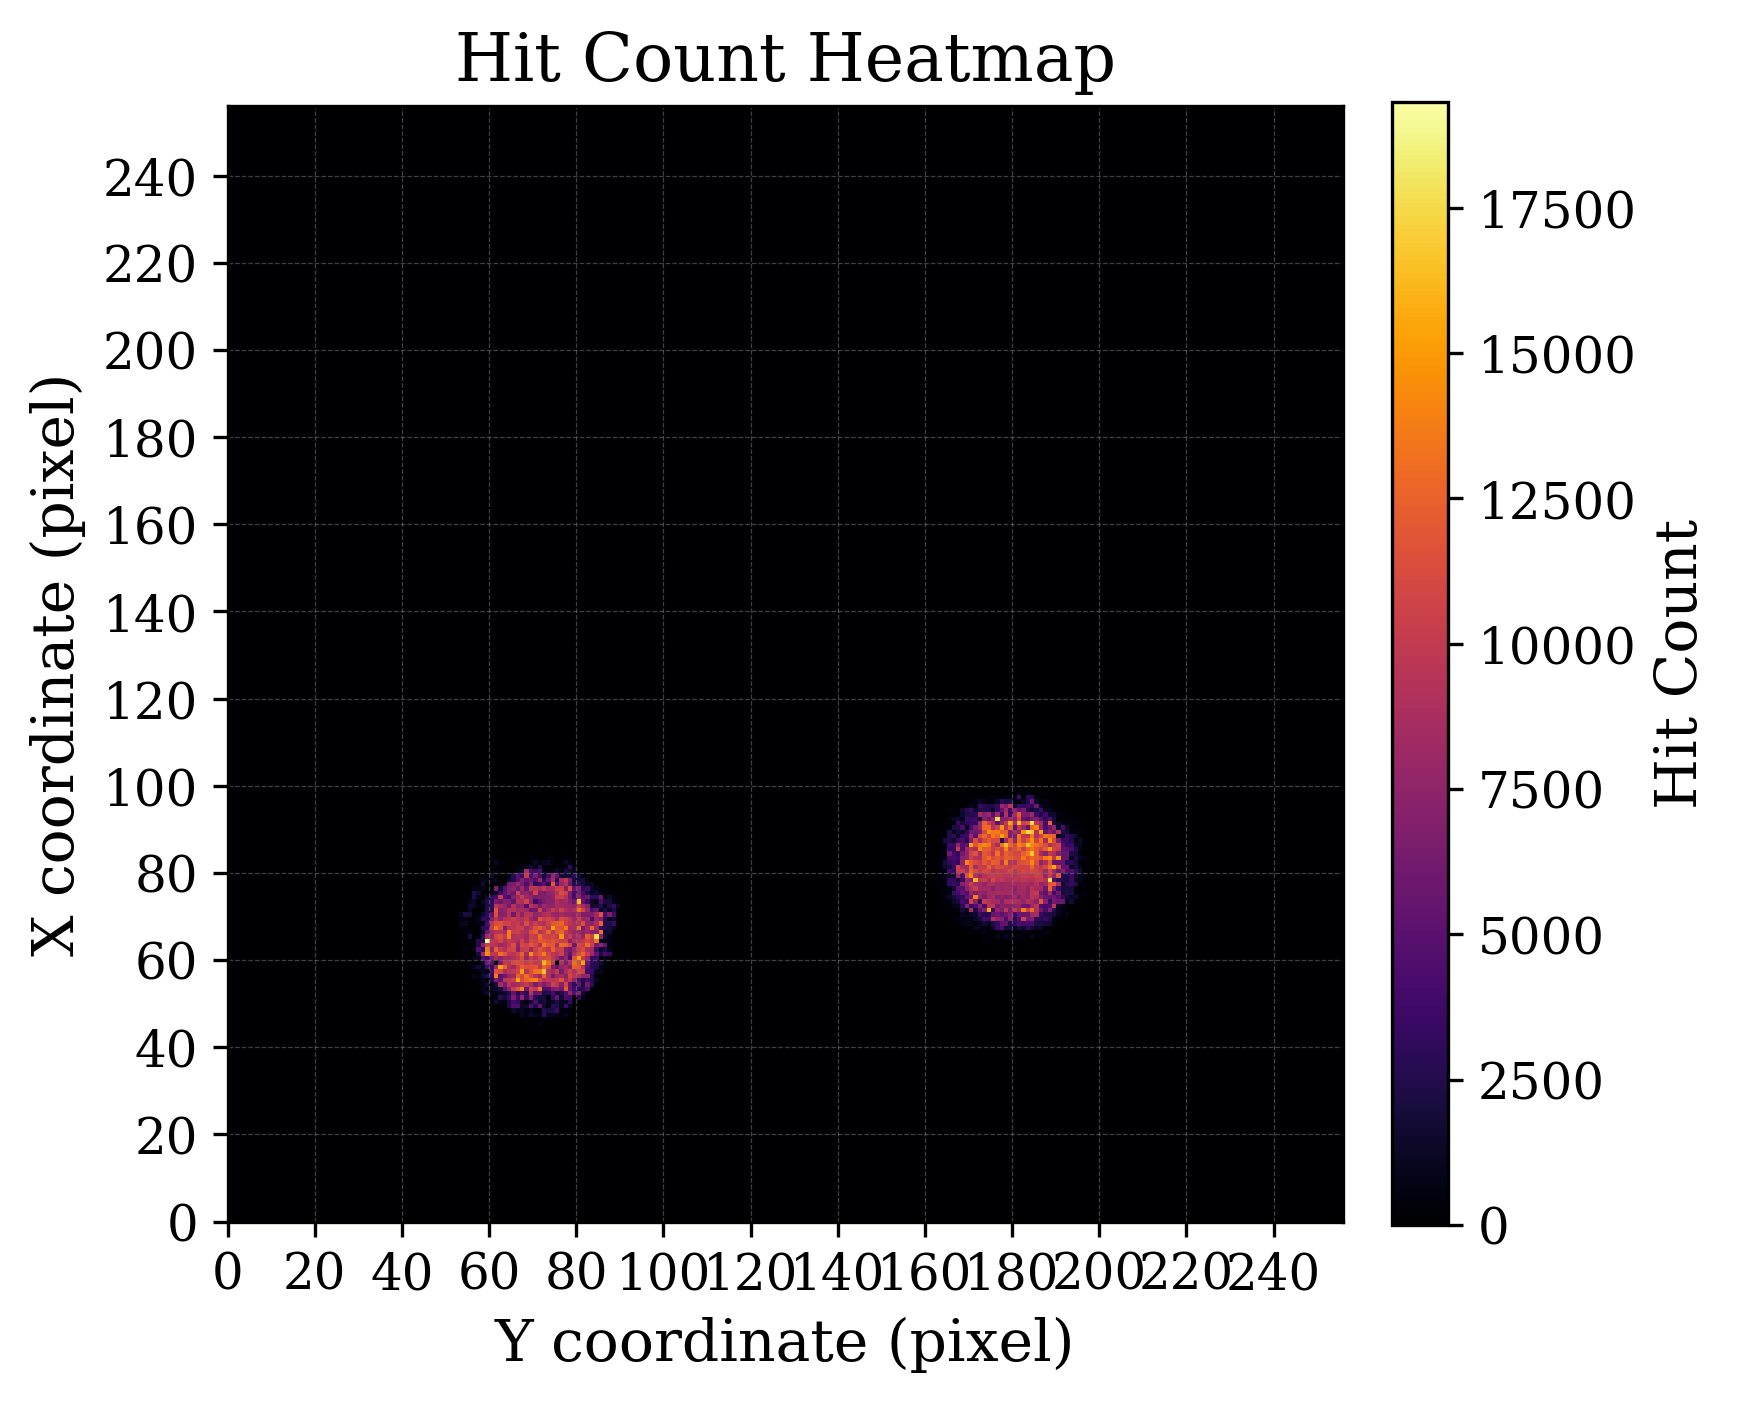

In [9]:
# Optional filter on ToT
data = data_processed.copy()

# Group by (x, y) and count entries
agg_data = data.groupby(['x', 'y']).size().reset_index(name='Count')

# Full 256x256 pixel grid
x_full = np.arange(0, 256)
y_full = np.arange(0, 256)
full_grid = pd.MultiIndex.from_product([x_full, y_full], names=['x', 'y']).to_frame(index=False)

# Merge and fill missing counts with 0
full_data = pd.merge(full_grid, agg_data, on=['x', 'y'], how='left')
full_data['Count'] = full_data['Count'].fillna(0)

# Pivot for heatmap
heatmap_data = full_data.pivot(index='x', columns='y', values='Count')

# --- Plotting ---
plt.rcParams.update({
    "font.size": 14,
    "font.family": "serif",   # For professional look; use 'sans-serif' if journal prefers
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 300
})

fig, ax = plt.subplots(figsize=(6, 5.5))  # Use size appropriate for 1-column journal layout

# Heatmap
cax = ax.imshow(
    heatmap_data.values,
    cmap='inferno',
    origin='lower',
    vmin=0,
    vmax=full_data['Count'].max(),
    extent=[0, 256, 0, 256],
    interpolation='none'
)

# Colorbar
cbar = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Hit Count', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Labels
ax.set_xlabel('Y coordinate (pixel)')
ax.set_ylabel('X coordinate (pixel)')
ax.set_title('Hit Count Heatmap')

# Grid settings
ax.set_xticks(np.arange(0, 257, 20))
ax.set_yticks(np.arange(0, 257, 20))
ax.grid(which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.5)

# Minor grid for clarity if needed
# ax.set_xticks(np.arange(0.5, 256.5, 1), minor=True)
# ax.set_yticks(np.arange(0.5, 256.5, 1), minor=True)
# ax.grid(which='minor', linestyle='-', linewidth=0.2, color='gray', alpha=0.3)

# Tight and square layout
ax.set_aspect('equal')
plt.tight_layout()

# Save figure (optional)
# plt.savefig("hit_count_heatmap.png", dpi=600, bbox_inches='tight')

plt.show()


iv. Save processed data

In [ ]:
data_processed.to_csv("D:\\Desktop\\Timepix\\Data with He Ni\\Measurement_apr_19_2025_17h01m31s\\raw\\processed_data.csv")

In [ ]:
data_main[(data_main["ToA"]<) and (data_main["ToA"]>)].to_csv("E:\\Desktop\\Timepix\\Data with He Ni\\trial.csv")

# 4: Visualize Data Parameters

i. Number of datapoints in each cluster

In [10]:
print("Number of datapoints in ch1: ", len(data1))
print("Number of datapoints in ch2: ", len(data2))

Number of datapoints in ch1:  6163590
Number of datapoints in ch2:  5654461


In [11]:
(len(data1)-len(data2))/len(data1)

0.08260267149502157

In [ ]:
def get_distribution(data: pd.DataFrame, x: int, y: int, steps=0.1):
    data_main = data[(data["x"] == x) & (data["y"] == y)]

    if data_main.empty:
        return None, None  # Return None if no data for the given (X, Y)

    t_max = round(data_main["ToA_corrected"].max())

    counts = []
    time_interval = np.arange(steps, t_max + steps, steps)

    j = 0
    for i in time_interval:
        data_new = data_main[(data_main["ToA_corrected"] > j) & (data_main["ToA_corrected"] < i)]
        counts.append(data_new.shape[0])
        j = i

    # Plot the distribution
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(time_interval, counts, width=steps, align='edge', edgecolor='black')
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Counts per interval")
    ax.set_title("Time-Binned Histogram of ToA_corrected Events")
    ax.grid(True)
    fig.tight_layout()
    ax.grid()

    return fig, ax

def find_1to1_matching(c1_df, c2_df, tolerance=0.05):
    """
    Find one-to-one matches between (X, Y) pixels from cluster 0 and cluster 1 
    such that their counts are within a given tolerance and no repeats occur.
    
    Parameters:
    - c1_df, c2_df: DataFrames with columns ['X', 'Y', 'count']
    - tolerance: allowable relative difference

    Returns:
    - matched_pairs: DataFrame with matched (X_c1, Y_c1, count_c1) <-> (X_c2, Y_c2, count_c2)
    """
    # Make mutable copies
    c2_remaining = c2_df.copy()
    used_c2_indices = set()
    matches = []

    for idx1, row1 in c1_df.iterrows():
        count1 = row1['count']
        best_match = None
        best_diff = float('inf')
        best_idx2 = None

        for idx2, row2 in c2_remaining.iterrows():
            if idx2 in used_c2_indices:
                continue
            count2 = row2['count']
            rel_diff = abs(count1 - count2) / max(count1, count2)

            if rel_diff <= tolerance and rel_diff < best_diff:
                best_diff = rel_diff
                best_match = row2
                best_idx2 = idx2

        if best_match is not None:
            matches.append({
                'X_c1': row1['x'], 'Y_c1': row1['y'], 'count_c1': count1,
                'X_c2': best_match['x'], 'Y_c2': best_match['y'], 'count_c2': best_match['count'],
                'rel_diff': best_diff
            })
            used_c2_indices.add(best_idx2)

    return pd.DataFrame(matches).sort_values('rel_diff')

def c12_correspondence(grouped_df_c1, grouped_df_c2, tolerance=0.05):
    grouped_df_c1 = (
        grouped_df_c1.groupby(["x", "y"])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
    )
    grouped_df_c2 = (
        grouped_df_c2.groupby(["x", "y"])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
    )

    matched = find_1to1_matching(grouped_df_c1, grouped_df_c2, tolerance)

    return matched


ii. Time Distribution of a pixel

In [ ]:
x = 81
y = 61

fig, ax = get_distribution(data_processed, x, y, 0.5)
fig.show()

iii. Correspondence between 2 clusters

In [ ]:
matched  = c12_correspondence(data1, data2, np.inf)
matched

In [ ]:
x1 = 77
y1 = 60

matched_data = matched[(matched["X_c1"]==x1) & (matched["Y_c1"]==y1)]
x2 = int(matched_data["X_c2"])
y2 = int(matched_data["Y_c2"])

fig1, ax1 = get_distribution(data_processed, x1, y1, 0.5)
fig1.show()

fig2, ax2 = get_distribution(data_processed, x2, y2, 0.5)
fig2.show()

In [ ]:
x2 = 77
y2 = 60

matched_data = matched[(matched["X_c2"]==x2) & (matched["Y_c2"]==y2)]
x1 = int(matched_data["X_c1"])
y1 = int(matched_data["Y_c1"])

fig1, ax1 = get_distribution(data_processed, x1, y1, 0.5)
fig1.show()

fig2, ax2 = get_distribution(data_processed, x2, y2, 0.5)
fig2.show()

# 5. G2T

In [12]:
# Convert to NumPy arrays
# toa1 = data1["ToA"].to_numpy()
# toa2 = data2["ToA"].to_numpy()

toa1 = data1["GlobalTime"].to_numpy()
toa2 = data2["GlobalTime"].to_numpy()


# toa1 = data_main["Chnl1"].to_numpy()
# toa2 = data_main["Chnl2"].to_numpy()

In [13]:
toa1

array([0.00124996, 0.00125022, 0.00125182, ..., 0.50003551, 0.5000318 ,
       0.50004077], shape=(6163590,))

In [15]:
toa1 = toa1[~np.isnan(toa1)]
toa2 = toa2[~np.isnan(toa2)]

In [16]:
def filter_min_gap(toa, min_gap=1e-5):
    result = [toa[0]]
    last = toa[0]
    
    for t in toa[1:]:
        if t - last >= min_gap:
            result.append(t)
            last = t
    return np.array(result)

In [17]:
toa1_new = filter_min_gap(toa1)
toa2_new = filter_min_gap(toa2)

In [18]:
data_final = pd.DataFrame({
    'chn1': toa1_new,
    'chn2': toa2_new[:len(toa1_new)]
})
data_final

,chn1,chn2
0,0.001250,0.001218
1,0.001261,0.001228
2,0.001274,0.001239
3,0.001285,0.001252
4,0.001327,0.001278
...,...,...
24084,0.499973,0.362659
24085,0.499984,0.362669
24086,0.500002,0.362709
24087,0.500028,0.362719


In [23]:
data_final = data_final[:5000]

In [28]:
data_final.to_csv("E:\\Desktop\\Timepix\\Data with He Ni\\same_intensity_timepix\\1s_1f_1_processed_same_gap_10um_tpx.csv", index=False)

In [21]:
just_less = -50e-6
just_greater = 50e-6
dt = 1e-6

In [ ]:
# x = np.arange(just_less, just_greater, dt)

# counts = [0]*len(x)
# corrector = -1*(just_less//dt)

# for ToA1 in toa1:
#     for ToA2 in toa2:
#         Tau = ToA2 - ToA1
#         if Tau>=just_less and Tau<=just_greater:
#             idx = int(np.floor((Tau - just_less)/dt))
#             counts[idx] += 1

# counts

In [ ]:
x = np.arange(just_less, just_greater, dt)
counts = np.zeros(len(x), dtype=int)

for t1 in toa1:
    taus = toa2 - t1

    # Filter taus within the range
    mask = (taus >= just_less) & (taus < just_greater)
    valid_taus = taus[mask]

    # Compute bin indices for valid taus
    bin_indices = ((valid_taus - just_less) // dt).astype(int)
    bin_indices = np.clip(bin_indices, 0, len(x) - 1)  # Prevent out-of-bounds
    counts += np.bincount(bin_indices, minlength=len(x))
    
counts

In [50]:
denominator = ((sum(counts/1000)/len(counts))*1000).astype(int)
denominator

np.int64(9922)

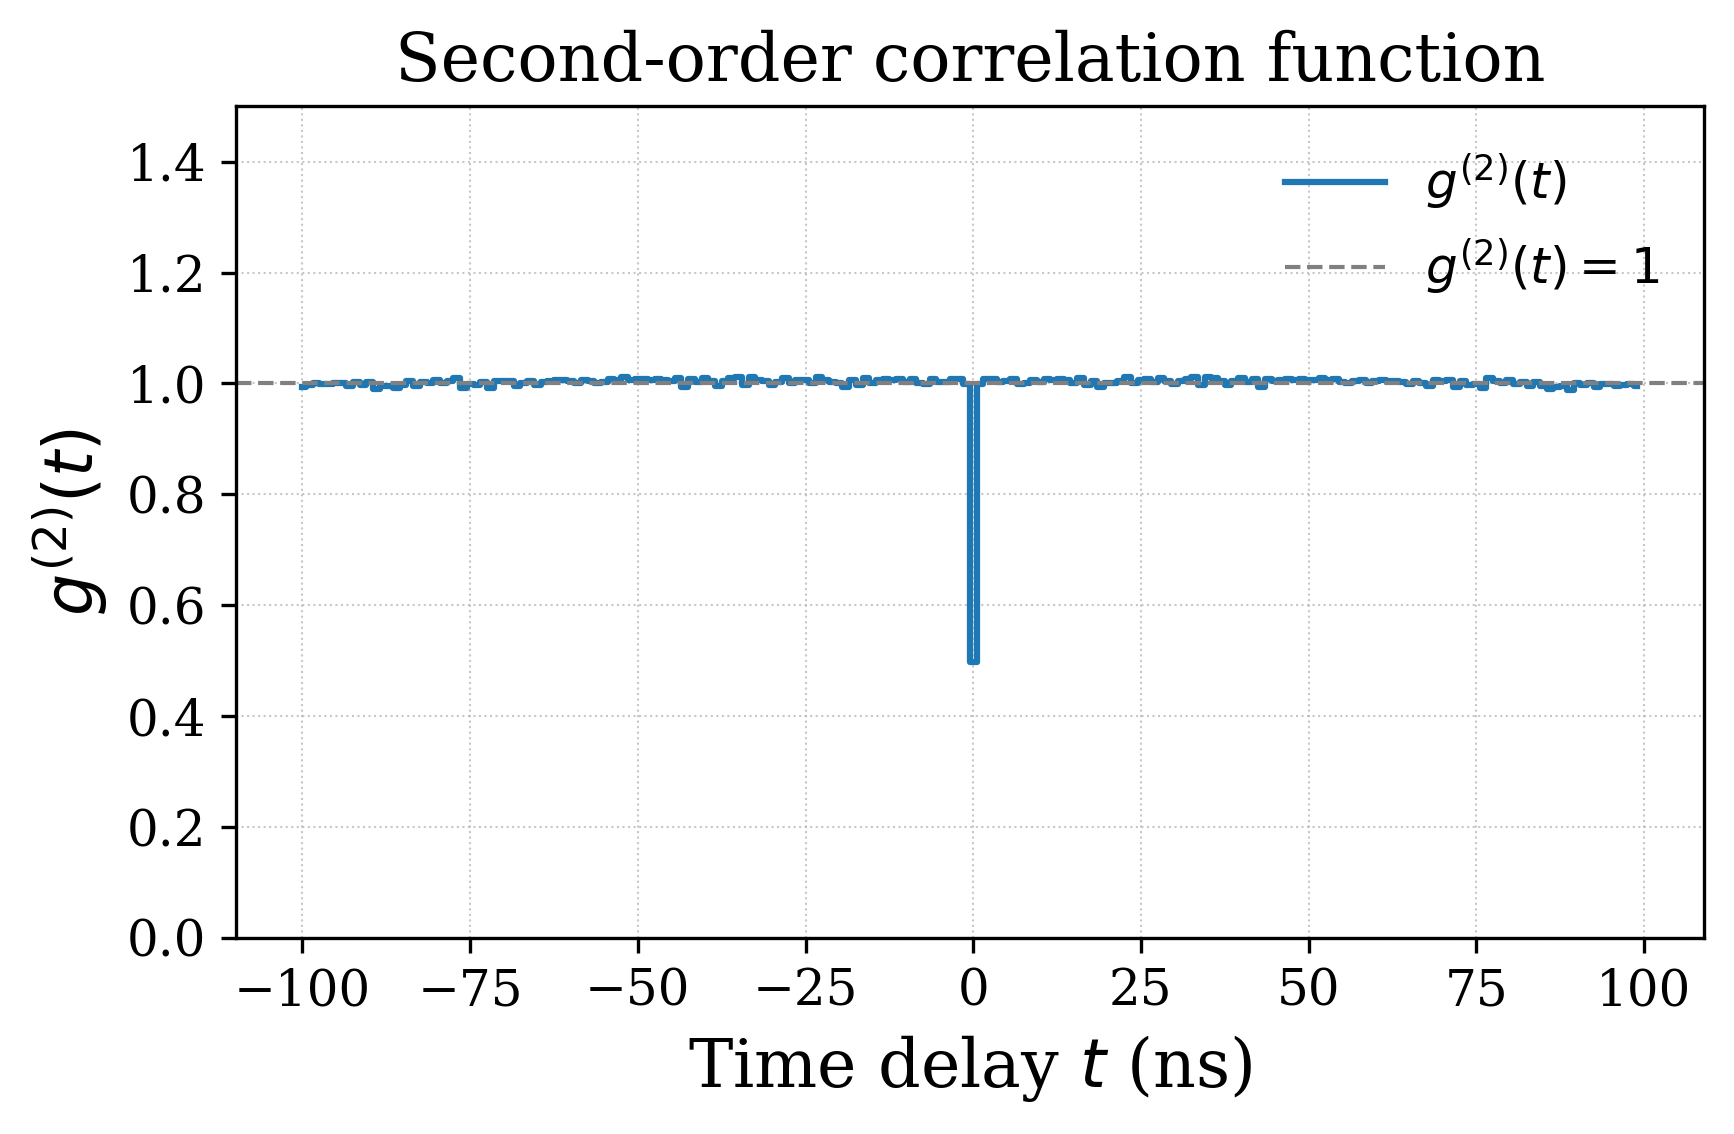

In [51]:
# Example: g2 = counts / denominator, x = time delays (in ns assumed)
# x, g2 already defined
g2 = np.array(counts)/ denominator
# g2 = np.where((g2 >= 0.75) & (g2 <= 1.25), g2, 1)

# Plot settings for paper
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.dpi": 300
})

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))  # Size fits single-column journal

# Plot g2 with step style
ax.plot(x, g2, drawstyle='steps-mid', color='tab:blue', linewidth=1.5, label=r"$g^{(2)}(t)$")

# Horizontal line at g²=1 (uncorrelated photons)
ax.axhline(1, color='gray', linestyle='--', linewidth=1, label=r"$g^{(2)}(t) = 1$")

# Axis labels and title
ax.set_xlabel(r"Time delay $t$ (ns)")
ax.set_ylabel(r"$g^{(2)}(t)$")
ax.set_ylim(0, 1.5)
ax.set_title(r"Second-order correlation function")

# Grid and legend
ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.7)
ax.legend(loc='best', frameon=False)

# Tight layout
plt.tight_layout()

# Optional: Save to file (high-res PNG or vector PDF)
# plt.savefig("g2_plot.pdf", format="pdf", bbox_inches="tight")
# plt.savefig("g2_plot.png", dpi=600, bbox_inches="tight")

plt.show()
